In [31]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [32]:
# define state
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    calc_bmi : float
    category : str

In [33]:
def level_bmi(state :BMIState)->BMIState:
    bmi = state['calc_bmi']
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state
        

In [34]:
def bmi_calculation(state :BMIState)->BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['calc_bmi'] = round(bmi,2)
    return state

In [35]:
# create graph
graph = StateGraph(BMIState)

# add_nodes
graph.add_node('bmi_calc', bmi_calculation)   # graph.add_node('node_name', node_function_name) may both same or different 
graph.add_node('level_bmi' ,level_bmi)

# add_edges
graph.add_edge(START, 'bmi_calc')  # graph.add_edge (START, 'node_name')
graph.add_edge('bmi_calc', 'level_bmi')
graph.add_edge('level_bmi', END)

# compile 
workflow = graph.compile()

In [36]:
# execution 
initial_state = {'weight_kg':60.0, 'height_m':1.6}
final_output = workflow.invoke(initial_state)
print(final_output)

{'weight_kg': 60.0, 'height_m': 1.6, 'calc_bmi': 23.44, 'category': 'Normal'}


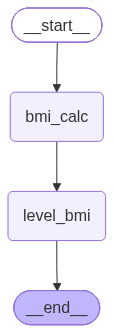

In [37]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))